In [11]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [16]:
%cd /content/drive/MyDrive/UCLA/Y5Q1/ECE 243A/ECE 234 - Project

/content/drive/MyDrive/UCLA/Y5Q1/ECE 243A/ECE 234 - Project


In [17]:
import torch
print("Torch version:", torch.__version__)

Torch version: 2.9.0+cu126


In [18]:
!pip install -e . --no-deps

Obtaining file:///content/drive/MyDrive/UCLA/Y5Q1/ECE%20243A/ECE%20234%20-%20Project
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for neural_decoder (pyproject.toml) ... done
  Created wheel for neural_decoder: filename=neural_decoder-0.0.1-0.editable-py3-none-any.whl size=1638 sha256=9501d5c8fc32064c465f24a28f63aef9b766e890201c2fb0221ee7422fcccc2f
  Stored in directory: /tmp/pip-ephem-wheel-cache-jkx1dnwf/wheels/e5/b6/e8/c63258f5758b1b402a45b1fbc9def56b6419e6bc2f57058020
Successfully built neural_decoder


In [19]:
%cd scripts

/content/drive/MyDrive/UCLA/Y5Q1/ECE 243A/ECE 234 - Project/scripts


In [20]:
!pip install edit_distance

In [21]:
!pip install hydra-core omegaconf

In [32]:
!python train_model_layernorm_residual.py

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
[Resume] Loading model weights from: /content/drive/MyDrive/UCLA/Y5Q1/ECE 243A/ECE 234 - Project/output/speechNormResidual_twoblock/modelWeights
[Resume] Found 30 eval points; resuming from batch 3000
/content/drive/MyDrive/UCLA/Y5Q1/ECE 243A/ECE 234 - Project/src/neural_decoder/augmentations.py:91: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1031.)
  return self.conv(input, weight=self.weight, groups=self.groups, padding="same")
/content/drive/MyDrive/UCLA/Y5Q1/ECE 243A/ECE 234 - Project/src/neural_decoder/neural_deco

In [33]:
import os
import pickle

model_dir = "/content/drive/MyDrive/UCLA/Y5Q1/ECE 243A/ECE 234 - Project/output/speechNormResidual_twoblock"

with open(os.path.join(model_dir, "trainingStats"), "rb") as f:
    stats = pickle.load(f)

testLoss = stats["testLoss"]
testCER  = stats["testCER"]

print("Loaded", len(testCER), "evaluation points")

Loaded 100 evaluation points


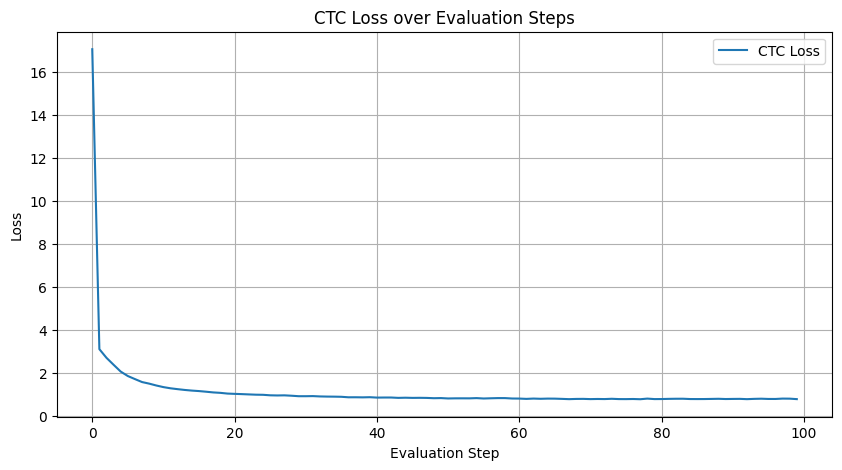

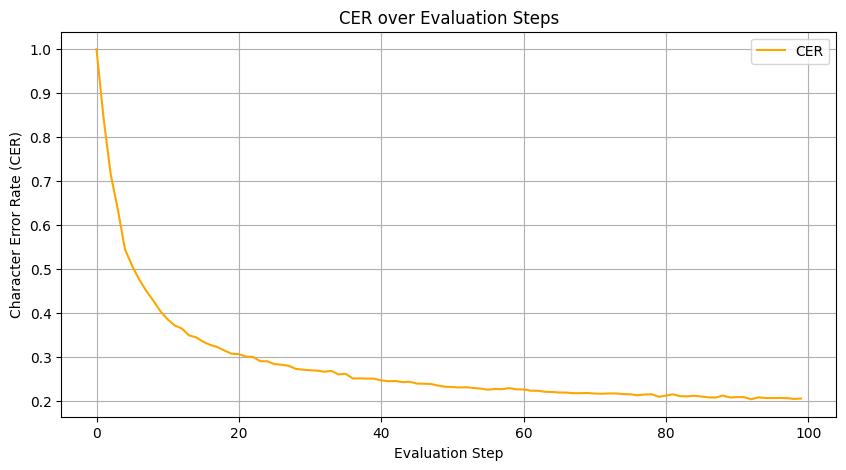

In [34]:
import matplotlib.pyplot as plt

# Plot CTC Loss
plt.figure(figsize=(10, 5))
plt.plot(testLoss, label="CTC Loss")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("CTC Loss over Evaluation Steps")
plt.grid(True)
plt.legend()
plt.show()

# Plot CER
plt.figure(figsize=(10, 5))
plt.plot(testCER, label="CER", color='orange')
plt.xlabel("Evaluation Step")
plt.ylabel("Character Error Rate (CER)")
plt.title("CER over Evaluation Steps")
plt.grid(True)
plt.legend()
plt.show()